In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("DailyDelhiClimateTest.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Set date as index
df.set_index('date', inplace=True)

# Display first rows
print(df.head())


             meantemp   humidity  wind_speed  meanpressure
date                                                      
2017-01-01  15.913043  85.869565    2.743478     59.000000
2017-01-02  18.500000  77.222222    2.894444   1018.277778
2017-01-03  17.111111  81.888889    4.016667   1018.333333
2017-01-04  18.700000  70.050000    4.545000   1015.700000
2017-01-05  18.388889  74.944444    3.300000   1014.333333


In [ ]:
print(df.describe())


         meantemp    humidity  wind_speed  meanpressure
count  114.000000  114.000000  114.000000    114.000000
mean    21.713079   56.258362    8.143924   1004.035090
std      6.360072   19.068083    3.588049     89.474692
min     11.000000   17.750000    1.387500     59.000000
25%     16.437198   39.625000    5.563542   1007.437500
50%     19.875000   57.750000    8.069444   1012.739316
75%     27.705357   71.902778   10.068750   1016.739583
max     34.500000   95.833333   19.314286   1022.809524


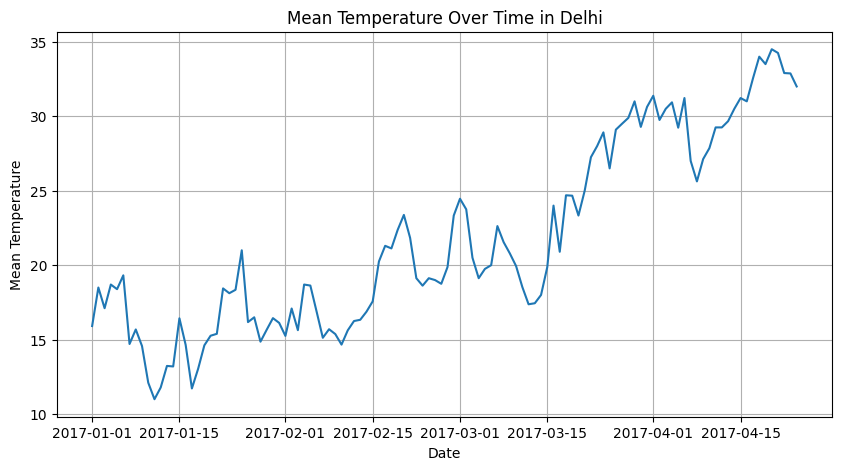

In [ ]:
#Plotting temp
plt.figure(figsize=(10,5))
plt.plot(df.index, df['meantemp'])
plt.title("Mean Temperature Over Time in Delhi")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.grid(True)
plt.show()


Observation

The plot shows fluctuating temperature values over time, indicating daily variations in Delhi's climate.

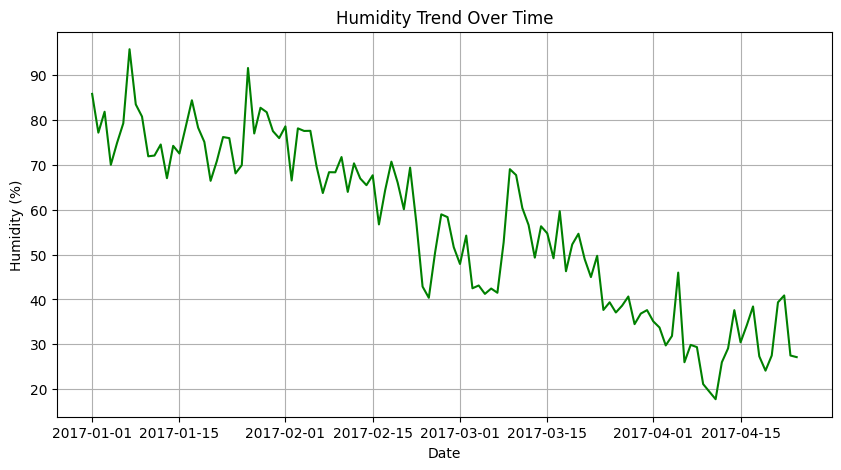

In [ ]:
#Plotting humidity
plt.figure(figsize=(10,5))
plt.plot(df.index, df['humidity'], color='green')
plt.title("Humidity Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.show()


Observation

Humidity levels show significant variation, reflecting different weather conditions across days.

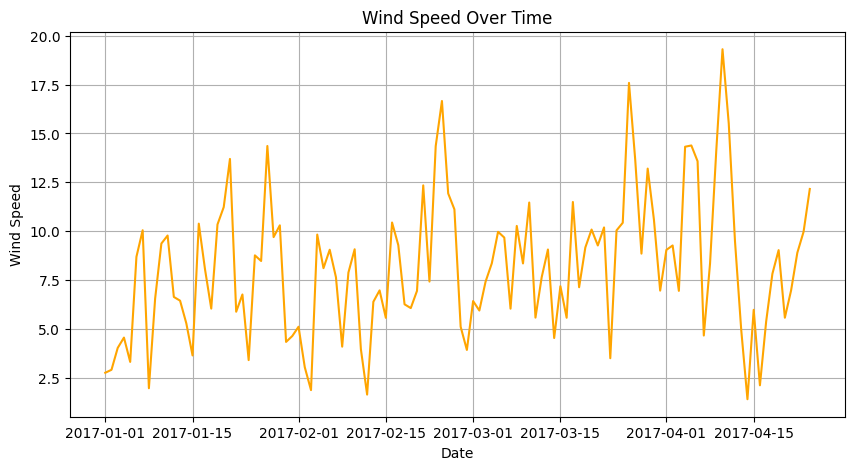

In [ ]:
#plotting wind speed
plt.figure(figsize=(10,5))
plt.plot(df.index, df['wind_speed'], color='orange')
plt.title("Wind Speed Over Time")
plt.xlabel("Date")
plt.ylabel("Wind Speed")
plt.grid(True)
plt.show()


Observation

Wind speed shows moderate fluctuations, indicating natural variation in atmospheric conditions.


**The ADF test statistically checks whether a time series is stationary.**

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['meantemp'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -1.096474275875619
p-value: 0.7164758731775932


# Checking Seasonality (Time Series Decomposition)
**Seasonality refers to patterns that repeat over a fixed time period (daily, weekly, monthly, yearly)**

In [ ]:
### Testing For Stationarity

from statsmodels.tsa.stattools import adfuller

In [ ]:
test_result=adfuller(df['meantemp'])

In [ ]:
from statsmodels.tsa.stattools import adfuller

# H0: Mean temperature time series is non-stationary
# H1: Mean temperature time series is stationary

def adfuller_test(temp_series):

    result = adfuller(temp_series)

    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']

    for value, label in zip(result, labels):
        print(label + ' : ' + str(value))

    if result[1] <= 0.05:
        print("\nStrong evidence against the null hypothesis (H0).")
        print("Reject H0 → Mean temperature time series is stationary.")
    else:
        print("\nWeak evidence against the null hypothesis (H0).")
        print("Fail to reject H0 → Mean temperature time series is non-stationary.")

In [ ]:
adfuller_test(df['meantemp'])

ADF Test Statistic : -1.096474275875619
p-value : 0.7164758731775932
#Lags Used : 0
Number of Observations Used : 113

Weak evidence against the null hypothesis (H0).
Fail to reject H0 → Mean temperature time series is non-stationary.


In [ ]:
import matplotlib.pyplot as plt

def plot_rolling_stats(temp_series):

    rolling_mean = temp_series.rolling(window=12).mean()
    rolling_std = temp_series.rolling(window=12).std()

    plt.figure(figsize=(10,5))

    plt.plot(temp_series, color='blue', label='Original Temperature')
    plt.plot(rolling_mean, color='red', label='Rolling Mean')
    plt.plot(rolling_std, color='black', label='Rolling Std')

    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation (Stationarity Check)')
    plt.xlabel('Date')
    plt.ylabel('Mean Temperature')

    plt.show()


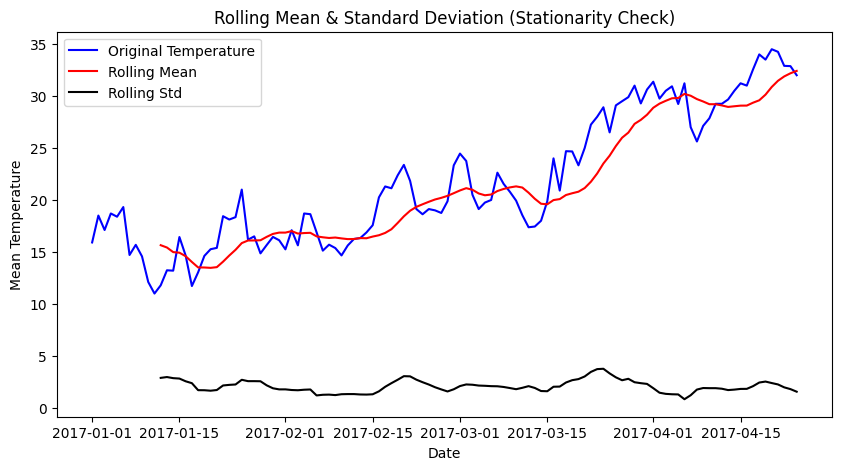

In [ ]:
plot_rolling_stats(df['meantemp'])

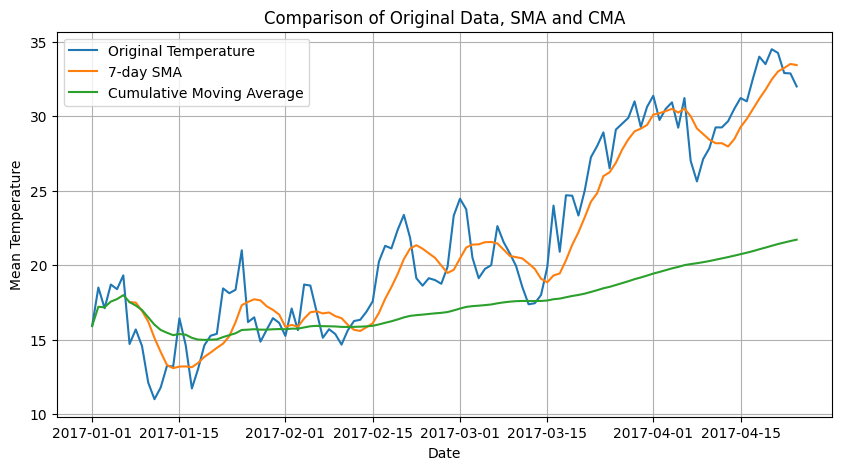

In [ ]:
import matplotlib.pyplot as plt

# Calculate SMA and CMA
df['SMA_7'] = df['meantemp'].rolling(window=7).mean()
df['CMA'] = df['meantemp'].expanding().mean()

# Plot all on same graph
plt.figure(figsize=(10,5))

plt.plot(df['meantemp'], label='Original Temperature')
plt.plot(df['SMA_7'], label='7-day SMA')
plt.plot(df['CMA'], label='Cumulative Moving Average')

plt.title("Comparison of Original Data, SMA and CMA")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")

plt.legend()
plt.grid(True)

plt.show()

#OBSERVATION
In this assignment, exploratory data analysis (EDA) was performed on the Delhi climate time series dataset. The dataset includes information about temperature, humidity, wind speed, and air pressure over time. Descriptive statistics and line plots were used to understand how these values change across different days.

The analysis showed that temperature, humidity, and wind speed change regularly, which reflects normal weather variations. Seasonal decomposition helped identify repeating patterns in the temperature data. Stationarity was also checked using rolling statistics and the Augmented Dickey–Fuller (ADF) test with statsmodels.

Overall, the analysis helped understand the patterns and behavior of the climate data. This step is important before applying time series forecasting models because it helps identify trends, seasonal patterns, and whether the data is stable over time.